In [1]:
# load relevant packages

import pandas as pd
import ast
import pysam
from Bio import SeqIO
import glob
import math
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from histogramplotter import *
import os
from dnds import dnds, pnps
import scipy.stats as stats
from scipy.stats import shapiro
# print(dnds.__file__)

from utils_nd import *
import argparse

In [2]:
# set up directories to which to point

experiment_id = 'jh_023' # user sets this
min_contexts = 7
# sets desired minimum contexts to be included in graphing

if experiment_id == 'jh_005':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/*'
    score_tag_name = 'normalized_score_lib'
elif experiment_id == 'jh_004':
    fasta_name = 'pmaa23_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'normalized_score_rep1_x'
elif experiment_id == 'jh_006':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'normalized_score_rep1_x'
elif experiment_id == 'jh_007':
    fasta_name = 'pmaa23_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'normalized_score_rep1'
    score_tag_name2 = 'normalized_score_rep2'
elif experiment_id == 'jh_008':
    fasta_name = 'pmaa23_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
    score_tag_name3 = 'replicate_3'
elif experiment_id == 'jh_009':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'normalized_score_rep1'
    score_tag_name2 = 'normalized_score_rep2'
elif experiment_id == 'jh_011':
    fasta_name = 'pjh1_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'normalized_score_rep1'
    score_tag_name2 = 'normalized_score_rep2'
elif experiment_id == 'jh_012':
    fasta_name = 'pjh2_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_013':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_014':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
    score_tag_name3 = 'replicate_3'
    score_tag_name4 = 'replicate_4'
elif experiment_id == 'jh_016':
    fasta_name = 'pjh2_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_017':
    fasta_name = 'pmaa23_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_018':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_019':
    fasta_name = 'pjh1_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_021':
    fasta_name = 'pjh2_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_022':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
elif experiment_id == 'jh_023':
    fasta_name = 'pjh3_nbonly'
    mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'replicate_1'
    score_tag_name2 = 'replicate_2'
    
    
cpm = '20'
csv_files = glob.glob(os.path.join(mutation_df_paths, f"dyn*scores*{cpm}*.csv"))
print(csv_files[-1])

../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/dyn2_library_scores_jh_023_countthresh20.csv


reference sequence: QVQLVESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS
wild type score: 0.8738941959230404
0    0.055967
1    0.708308
2    0.037575
3    0.576519
4    0.846124
Name: average normalized score, dtype: float64


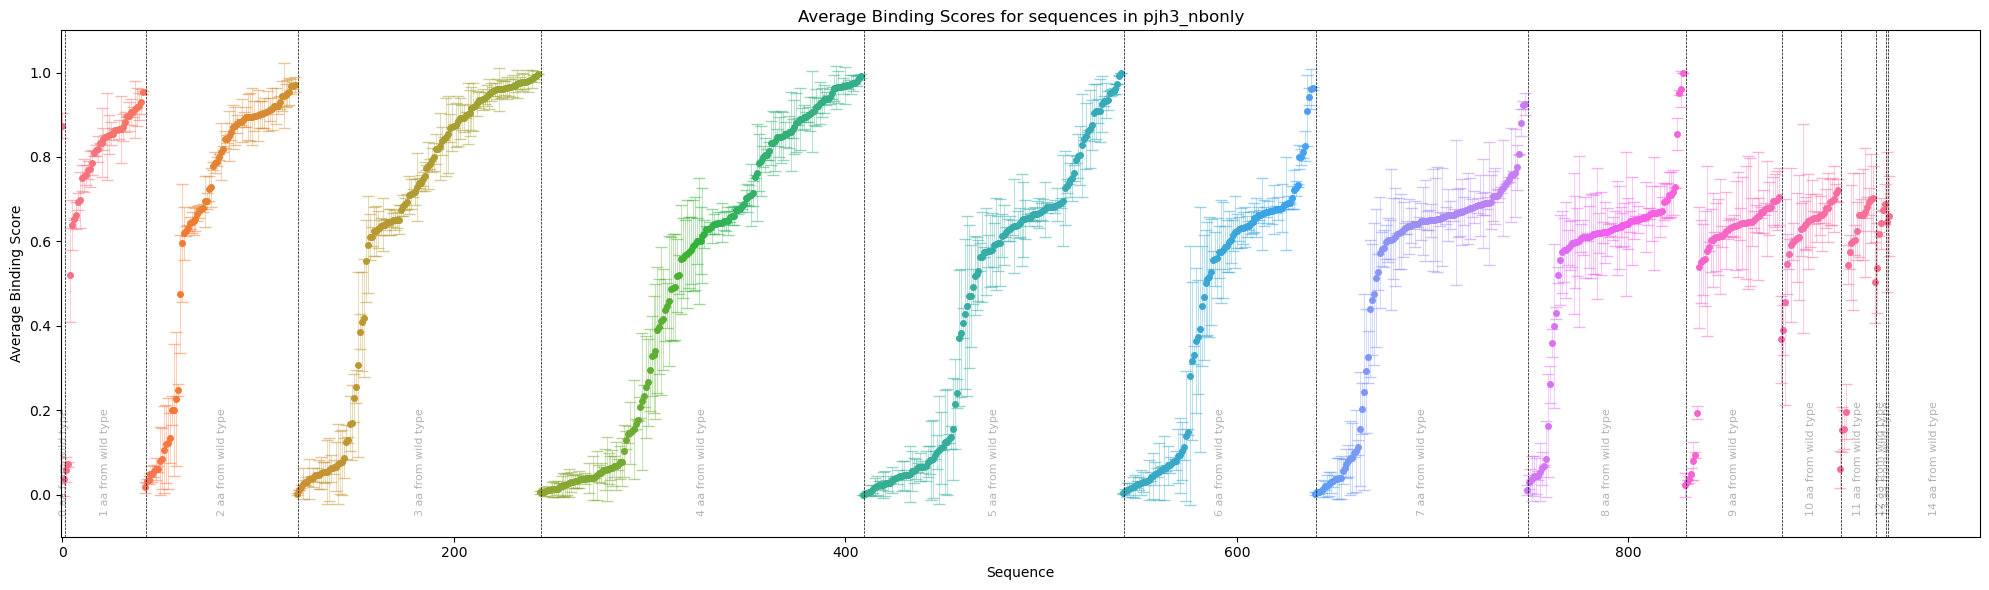

no sequences with high variance


In [3]:
for library_path in [csv_files[-1]]:
    # import and loading
    if experiment_id == 'jh_005':
        library_type = library_path.split('/')[-2]
        library_name = library_path.split('/')[-2] + '_' + experiment_id
        print(library_name)
    else:
        library_name = library_path.split('/')[-1]
    library_df = pd.read_csv(library_path, index_col=0)

    # reference specifications
    ref_fasta_path = f'../../minibinders_orthorep_data/ngs_raw/{experiment_id}/references/{fasta_name}.fasta'
    ref_fasta = SeqIO.read(ref_fasta_path, "fasta")
    parent_dna_seq = ref_fasta.seq
    parent_dna_id = ref_fasta.id
    
    parent_aa_seq = translate_sequence(parent_dna_seq)
    
    print(f"reference sequence: {parent_aa_seq}")

    
    # capture wild type score from dataframe
    try:
        wt_slice = library_df[library_df['aa_sequence'] == parent_aa_seq]
        # print(wt_slice)
        if wt_slice.empty:
            print("no wild type score found, using previous WT score")
            # if experiment_id == 'jh_009':
            #     wt_score = 1.0
        else:
            # print(wt_slice)
            if experiment_id == 'jh_004' or experiment_id == 'jh_005' or experiment_id == 'jh_006':
                wt_score = wt_slice[f'{score_tag_name}'].values[0]
            elif experiment_id == 'jh_008':
                # wt_scores_reps = [wt_slice[f'{score_tag_name}'].values[0], wt_slice[f'{score_tag_name2}'].values[0]]
                wt_score = np.mean([wt_slice[f'{score_tag_name}'].values[0],
                                    wt_slice[f'{score_tag_name2}'].values[0],
                                    wt_slice[f'{score_tag_name3}'].values[0]])
            elif experiment_id == 'jh_014':
                # wt_scores_reps = [wt_slice[f'{score_tag_name}'].values[0], wt_slice[f'{score_tag_name2}'].values[0]]
                wt_score = np.mean([wt_slice[f'{score_tag_name}'].values[0],
                                    wt_slice[f'{score_tag_name2}'].values[0],
                                    wt_slice[f'{score_tag_name3}'].values[0],
                                    wt_slice[f'{score_tag_name4}'].values[0]])
            else:
                # wt_score = wt_slice[f'{score_tag_name}'].values[0]
                wt_score = np.mean([wt_slice[f'{score_tag_name}'].values[0], wt_slice[f'{score_tag_name2}'].values[0]])
            print(f"wild type score: {wt_score}")
    except Exception as e:
        print(f"error: {e}")

    # simple graph for plotting averages and err for replicate scores
    if experiment_id == 'jh_007' or 'jh_009' or experiment_id == 'jh_011' or experiment_id == 'jh_012' or experiment_id == 'jh_013' or experiment_id == 'jh_016' or experiment_id == 'jh_017' or experiment_id == 'jh_018' or experiment_id == 'jh_019' or experiment_id == 'jh_021' or experiment_id == 'jh_022' or experiment_id == 'jh_023':
        library_df['average normalized score'] = library_df[[f'{score_tag_name}', f'{score_tag_name2}']].mean(axis=1)
        print(library_df['average normalized score'][:5])
        library_df['normalized score error'] = library_df[[f'{score_tag_name}', f'{score_tag_name2}']].std(axis=1)

        
        library_org_df = library_df.sort_values(by=['number_aa_mutations',
                                                    'average normalized score',
                                                    'normalized score error'])
    elif experiment_id == 'jh_008':
        library_df['average normalized score'] = library_df[[f'{score_tag_name}', f'{score_tag_name2}', f'{score_tag_name3}']].mean(axis=1)
        print(library_df['average normalized score'][:5])

        library_df['normalized score error'] = library_df[[f'{score_tag_name}', f'{score_tag_name2}', f'{score_tag_name3}']].std(axis=1)
        print(library_df['normalized score error'][:5])
        
        library_org_df = library_df.sort_values(by=['number_aa_mutations',
                                                    'average normalized score',
                                                    'normalized score error'])

    elif experiment_id == 'jh_014':
        library_df['average normalized score'] = library_df[[f'{score_tag_name}', f'{score_tag_name2}', f'{score_tag_name3}', f'{score_tag_name4}']].mean(axis=1)
        print(library_df['average normalized score'][:5])

        library_df['normalized score error'] = library_df[[f'{score_tag_name}', f'{score_tag_name2}', f'{score_tag_name3}', f'{score_tag_name4}']].std(axis=1)
        print(library_df['normalized score error'][:5])
        
        library_org_df = library_df.sort_values(by=['number_aa_mutations',
                                                    'average normalized score',
                                                    'normalized score error'])

        
    if experiment_id == 'jh_007' or experiment_id == 'jh_008' or experiment_id == 'jh_009' or experiment_id == 'jh_011' or experiment_id == 'jh_012' or experiment_id == 'jh_013' or experiment_id == 'jh_014' or experiment_id == 'jh_016' or  experiment_id == 'jh_017' or experiment_id == 'jh_018' or experiment_id == 'jh_019' or experiment_id == 'jh_021' or experiment_id == 'jh_022' or experiment_id == 'jh_023':
        org_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/seqs_avgscores.png'
        colors_org = sns.color_palette("husl", len(library_org_df))
        wtdistances_org = []
        high_var = []
        plt.figure(figsize=(20,6))
        for seq in range(len(library_org_df)):
            score_avg = library_org_df['average normalized score'].iloc[seq]
            score_err = library_org_df['normalized score error'].iloc[seq]
            plt.plot(seq, score_avg, marker = 'o', ms=4, color=colors_org[seq])
            plt.errorbar(seq, score_avg, yerr=score_err, capsize=4, elinewidth=0.5, alpha=0.5, color=colors_org[seq])
            wtdistances_org.append(library_org_df['number_aa_mutations'].iloc[seq])
            if score_err > (math.ceil(1/3*100)/100):
                high_var.append(seq)
            
        plt.xlabel('Sequence')
        plt.ylabel('Average Binding Score')
        plt.title(f'Average Binding Scores for sequences in {fasta_name}')
        # plt.legend(loc = 'upper right', bbox_to_anchor=(1.4, 1), borderaxespad=0, frameon=False)
        plt.ylim(-0.1,1.1)
        plt.xlim(-0.5,None)

        xmino, xmaxo = plt.xlim()
        linedist_org = []
        linedist_org.append(0)
        for disto in range(len(wtdistances_org[:-1])):
            if wtdistances_org[disto] != wtdistances_org[disto+1]:
                nextdisto = wtdistances_org[disto+1] - wtdistances_org[disto] # will determine the number of lines plotted
                for lineo in range(nextdisto):
                    linexo = (disto+1.5)+(lineo/nextdisto * 0.4) # max line occupancy is within 0.1 of the next context
                    plt.axvline(linexo, color = 'k', linestyle='--', linewidth=0.5)
                    linedist_org.append(linexo)
                # print(linedist_org)
                plt.text((linedist_org[-1]+linedist_org[-(int(nextdisto)+1)])/2, -0.05, f"{wtdistances_org[disto]} aa from wild type", ha='center', va='bottom', rotation = 90, alpha = 0.3, size = 8)
        plt.text((xmaxo+linedist_org[-1])/2, -0.05, f"{wtdistances_org[-1]} aa from wild type", ha='center', va='bottom', rotation = 90, alpha = 0.3, size = 8)                  
        plt.tight_layout()
        plt.savefig(org_outpath, bbox_inches='tight', dpi=400)
        plt.show()
        plt.close()

    if len(high_var) == 0:
        print('no sequences with high variance')
    else:
        print(f'{len(high_var)} sequence replicates with high variance')


there are 934 groups of single mutants
created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/
created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/P14S/


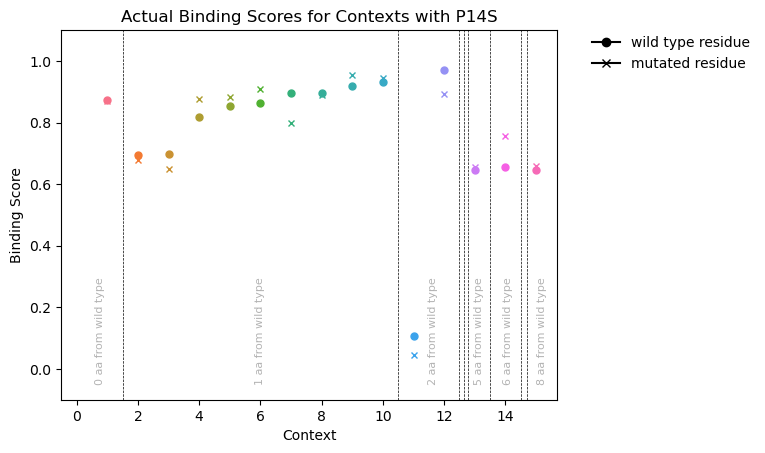

created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/G16D/


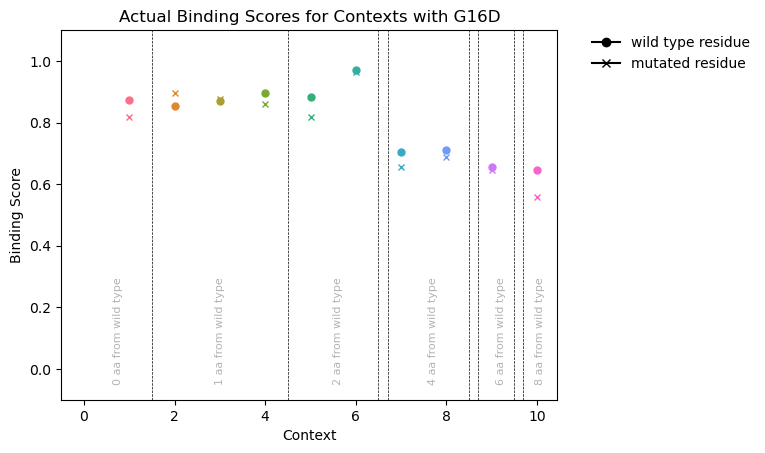

created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/A50T/


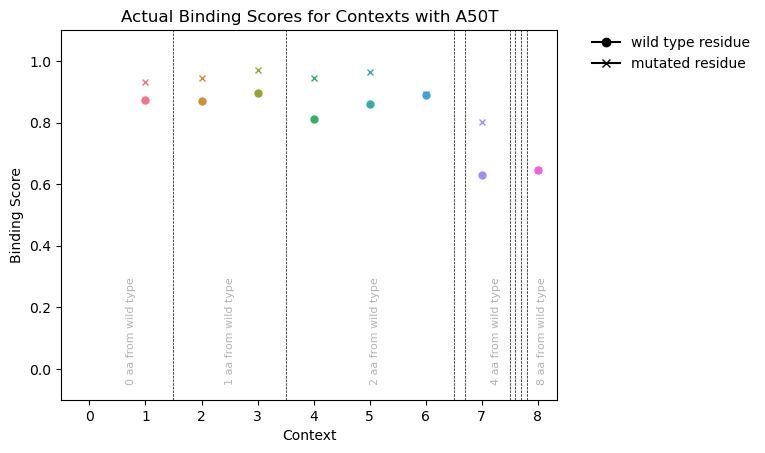

created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/A60T/


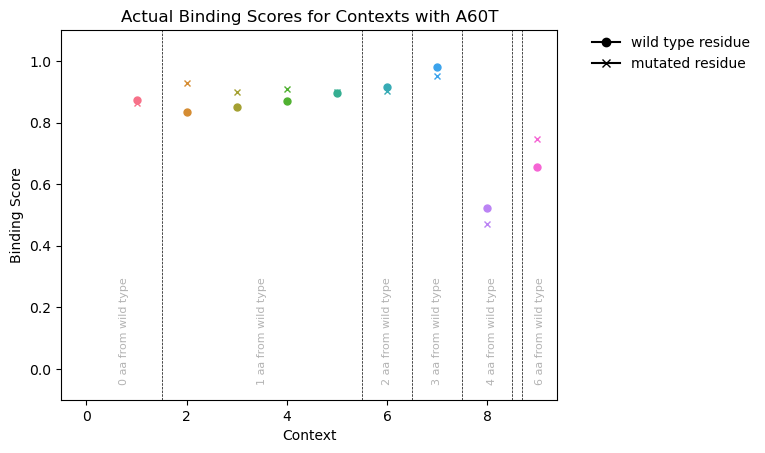

created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/T68M/


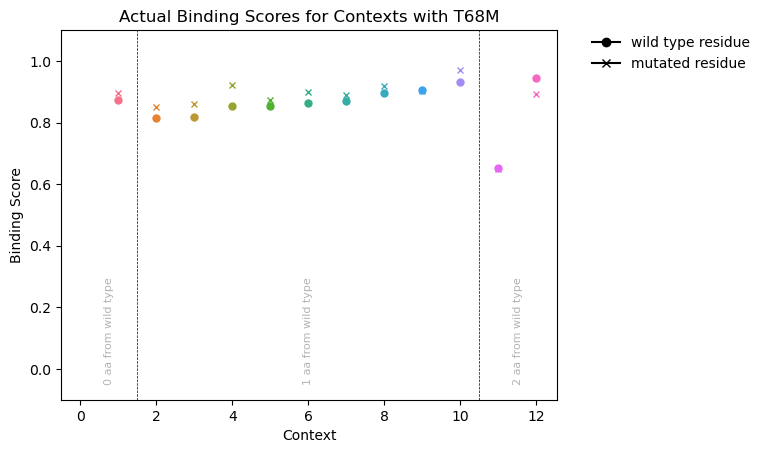

created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/A87V/


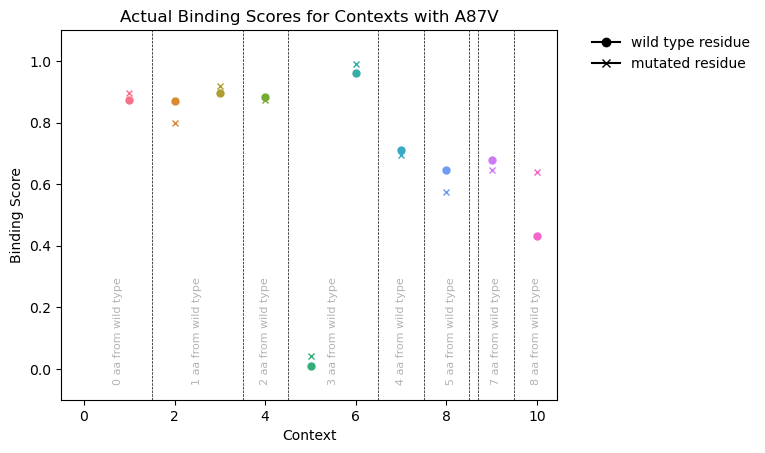

created folder : ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_023/neutral_drift_library/plots/point_mutations/G101D/


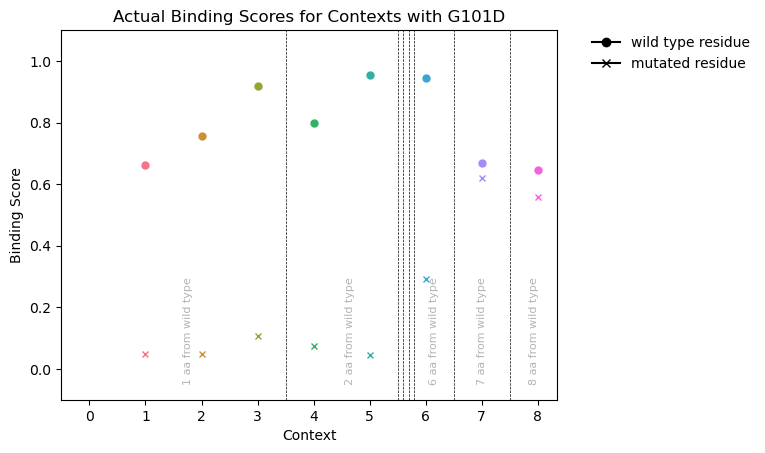

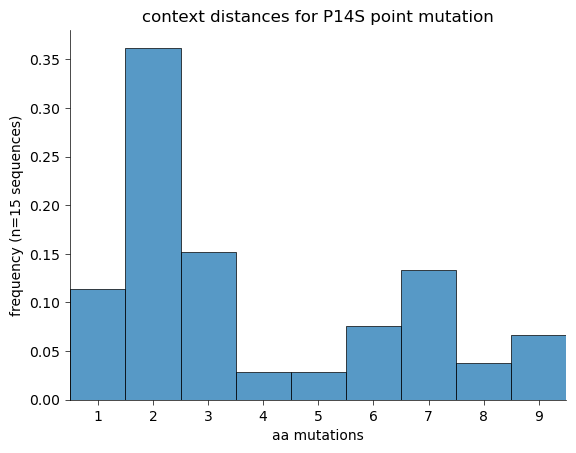

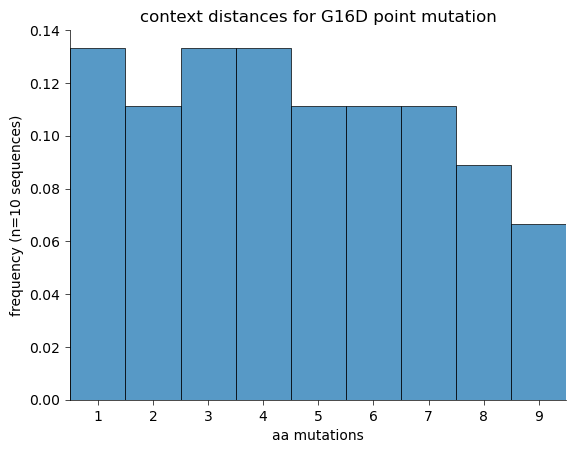

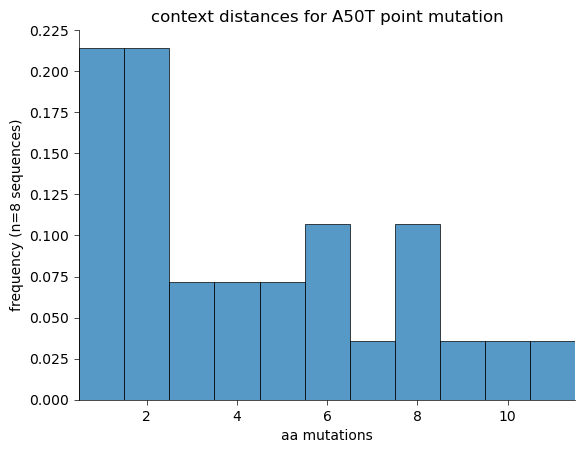

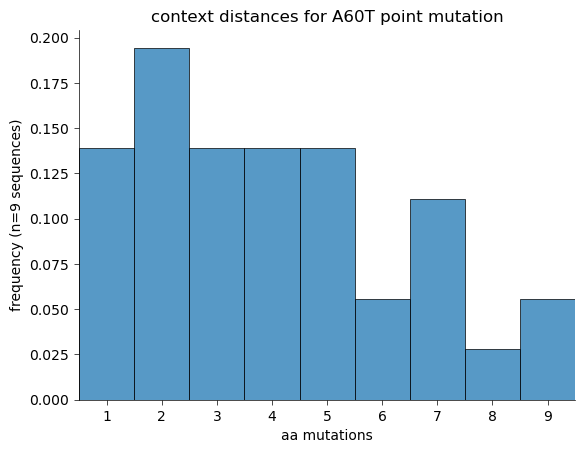

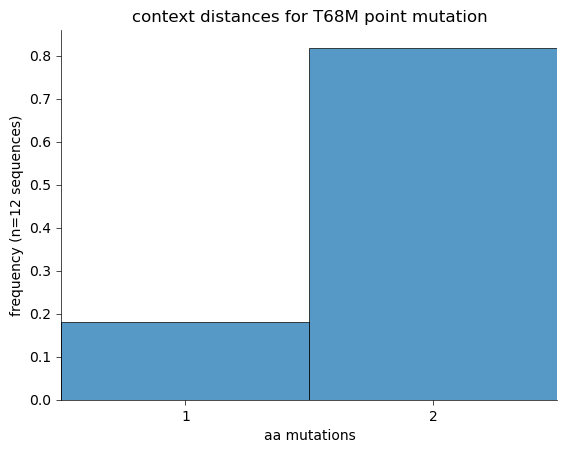

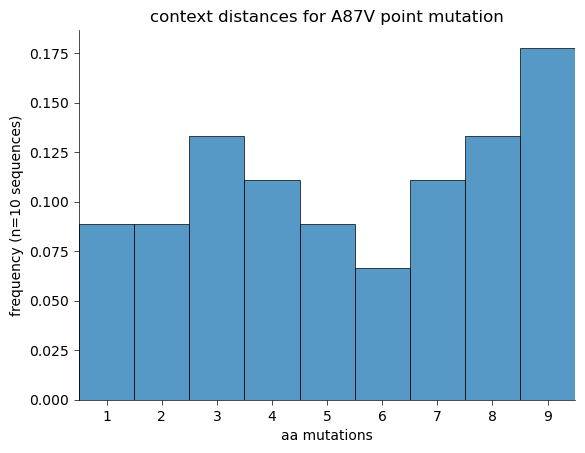

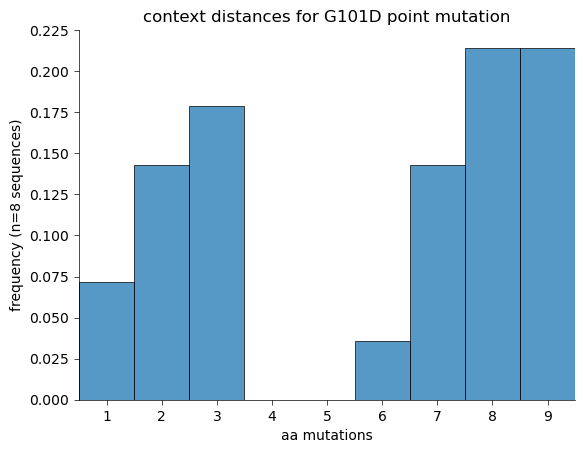

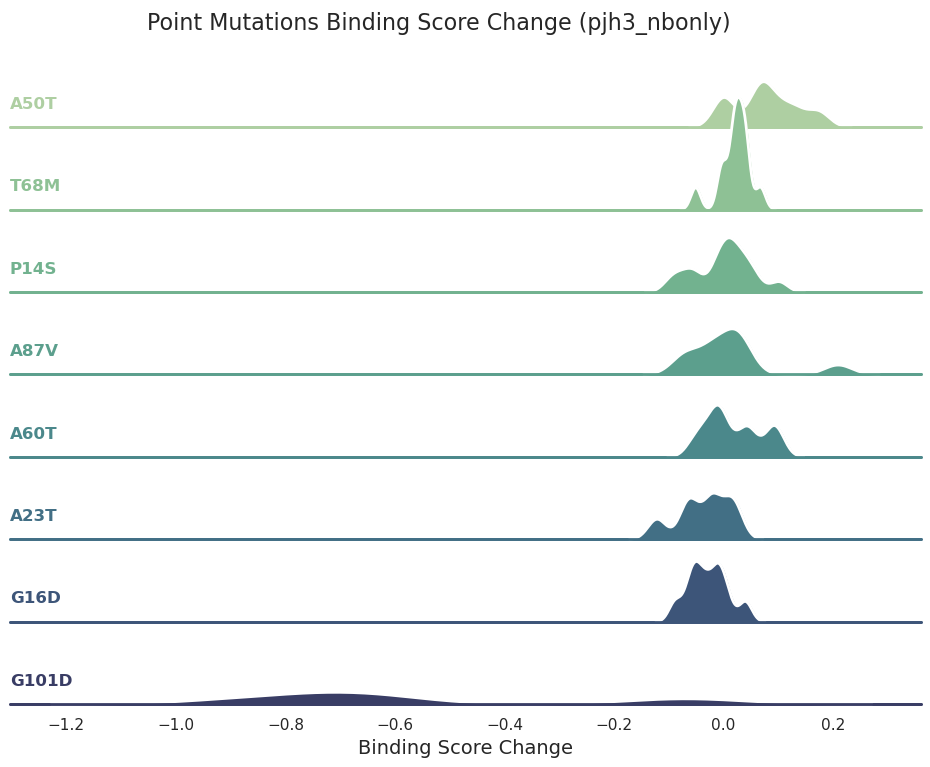

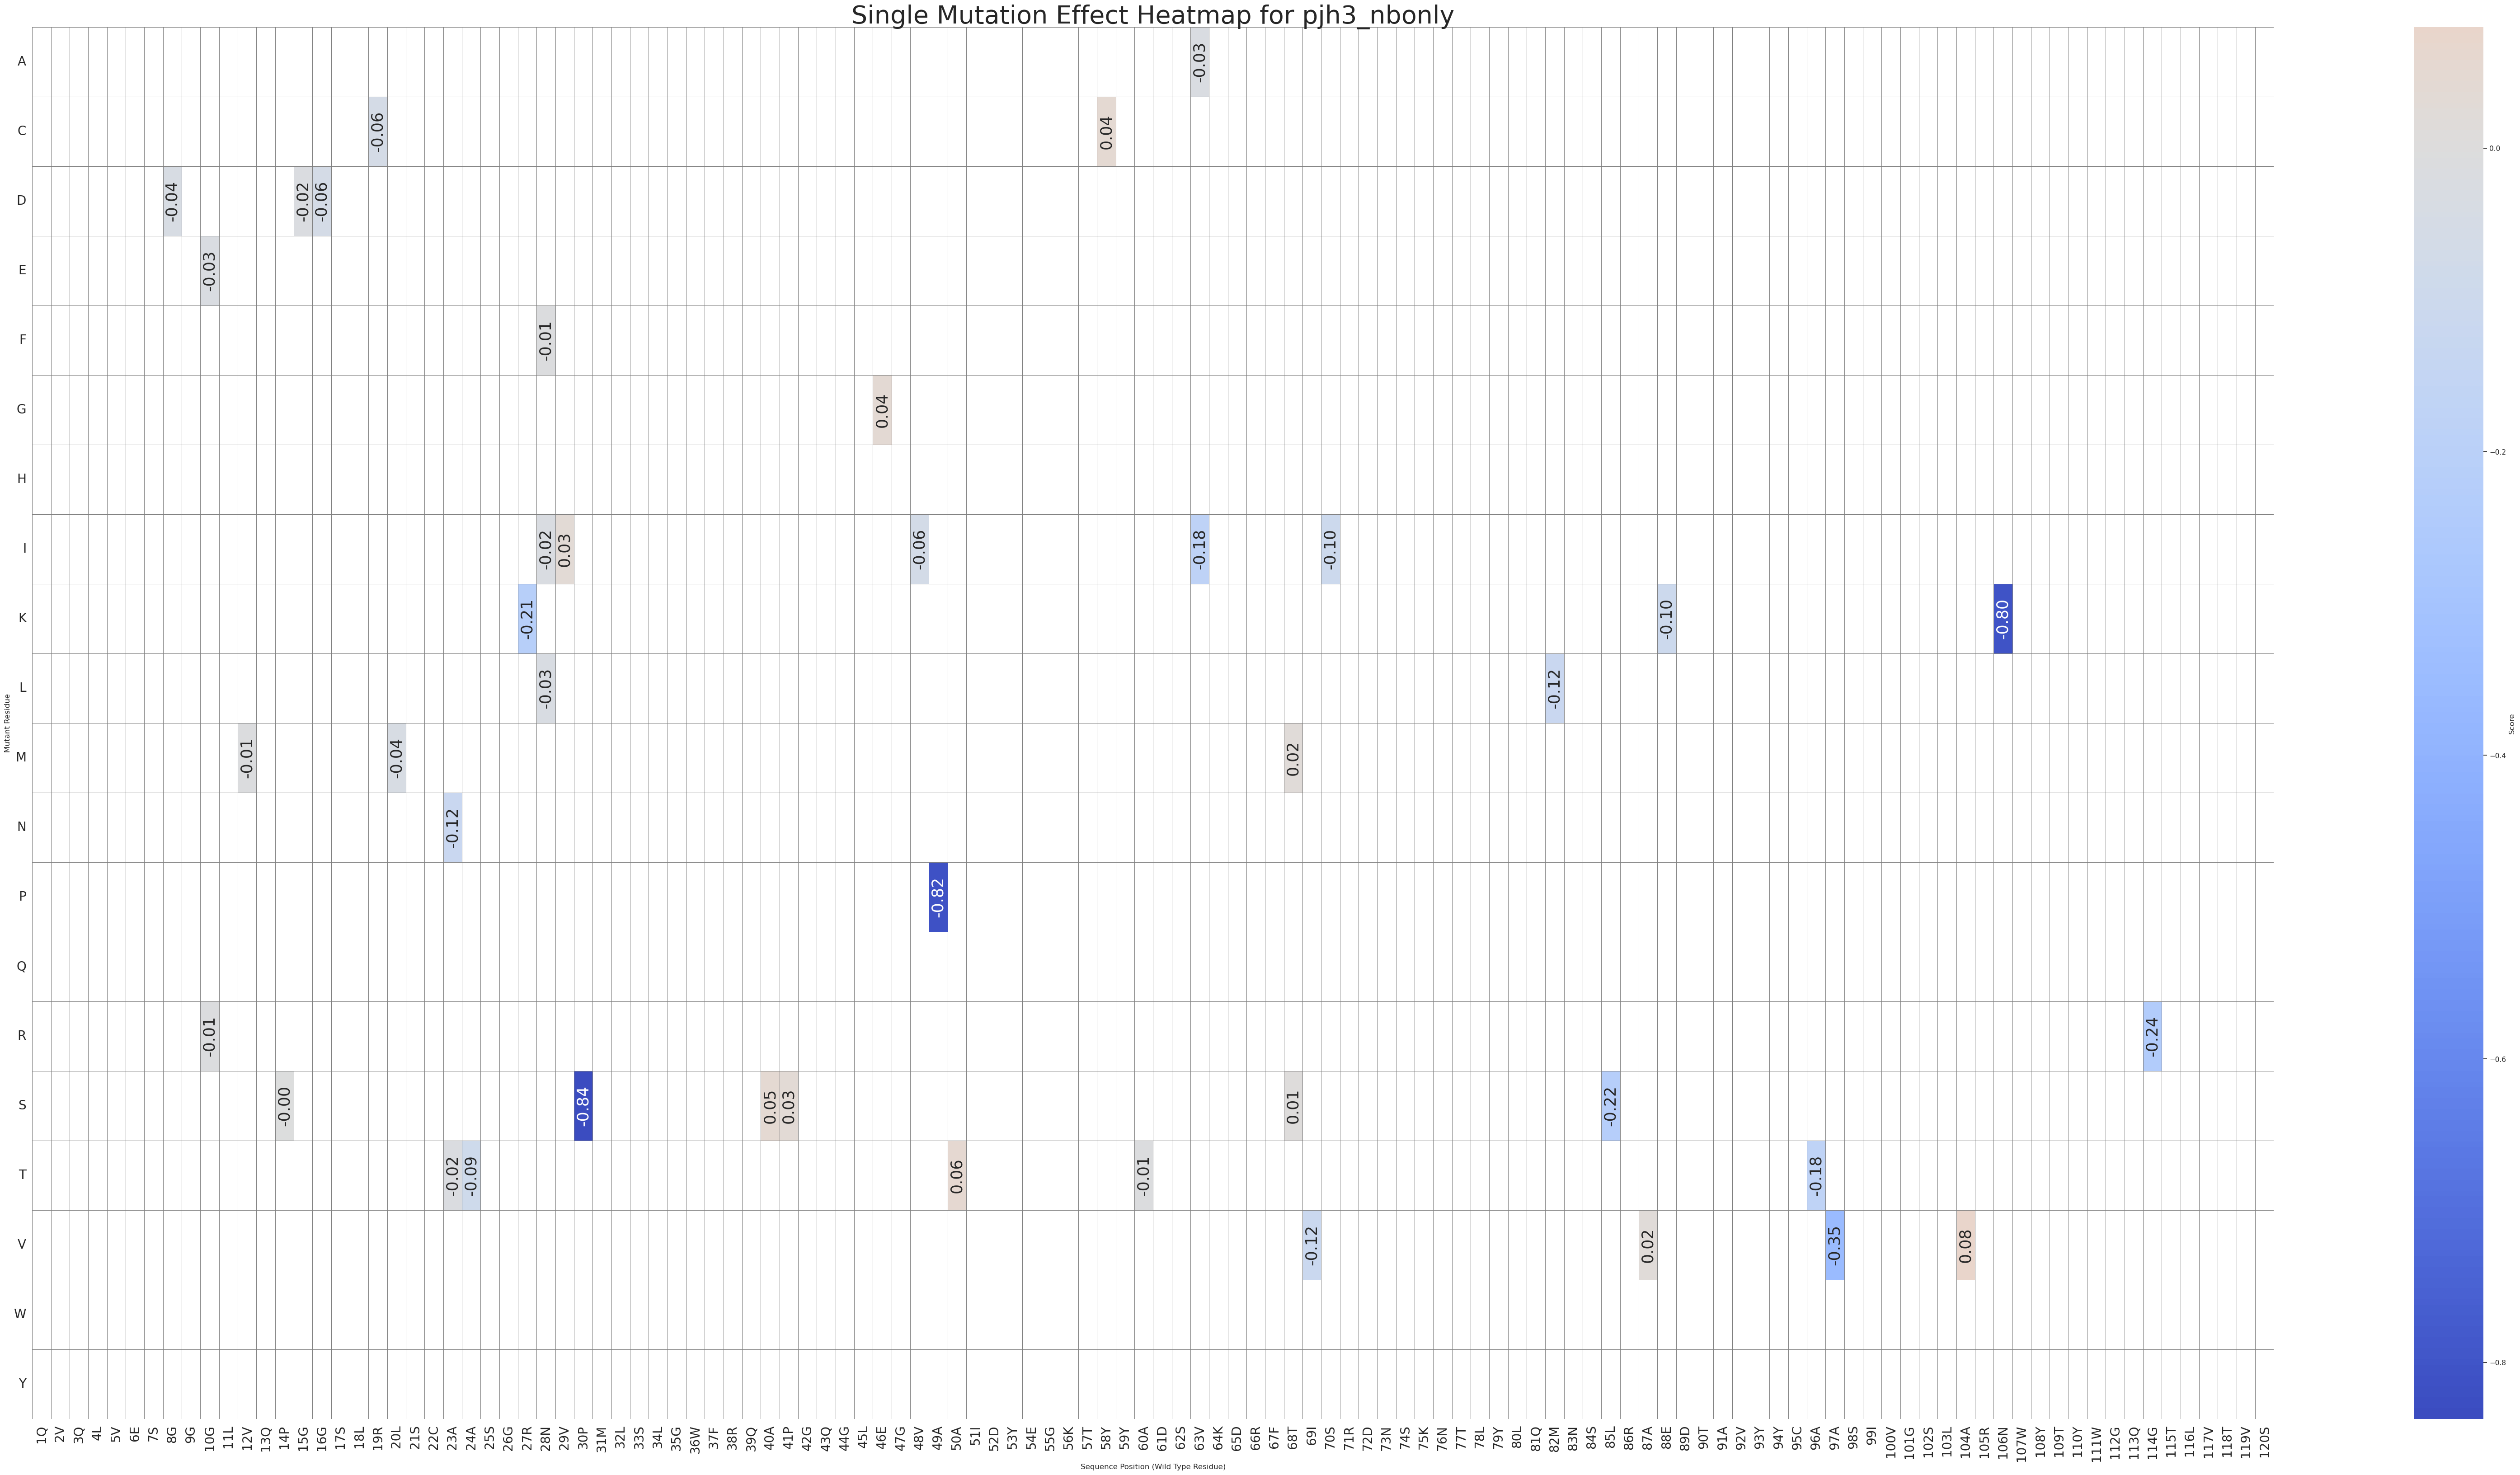

-------new library-------


In [4]:
    #create families of single mutants from aa sequences within the library
    
    lib_aaseq = library_df.sort_values('number_aa_mutations')['aa_sequence']
    # print(lib_aaseq[:5])

    # compile lists of single mutants of a given sequence (iterate through sequences in the set of scores in order)
    singlemuts = {}
    for i in range(len(lib_aaseq)):
        aaseq = lib_aaseq.iloc[i]
        singlemutlist = []
        # print(aaseq)
        for j in range(i+1, len(lib_aaseq)):
            seqcomp = lib_aaseq.iloc[j]
            if seqcomp != aaseq:
                hamming_pairwise_aa = hamming_distance(aaseq, seqcomp)
                # print(hamming_pairwise_aa)
                if hamming_pairwise_aa == 1:
                    singlemutlist.append(seqcomp)
        singlemuts[aaseq] = singlemutlist
    print(f"there are {len(list(singlemuts.keys()))} groups of single mutants")

    # comprehensive list of pairs of single mutants organized by point mutation

    mutrec = []
    
    for sequence in list(singlemuts.keys()):
        seqdist = hamming_distance(sequence, parent_aa_seq)
        for variant in list(singlemuts[sequence]):
            vardist = hamming_distance(variant, parent_aa_seq)
            if experiment_id == 'jh_004' or experiment_id == 'jh_005' or experiment_id == 'jh_006':
                scores = [library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name}'].values[0], 
                          library_df[library_df['aa_sequence'] == variant][f'{score_tag_name}'].values[0]]
            elif experiment_id == 'jh_008':
                scores = [np.mean([library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name}'].values[0],
                                   library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name2}'].values[0],
                                   library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name3}'].values[0]]),
                          np.mean([library_df[library_df['aa_sequence'] == variant][f'{score_tag_name}'].values[0],
                                   library_df[library_df['aa_sequence'] == variant][f'{score_tag_name2}'].values[0],
                                   library_df[library_df['aa_sequence'] == variant][f'{score_tag_name3}'].values[0]])]
            elif experiment_id == 'jh_014':
                scores = [np.mean([library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name}'].values[0],
                                   library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name2}'].values[0],
                                   library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name3}'].values[0],
                                   library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name4}'].values[0]]),
                          np.mean([library_df[library_df['aa_sequence'] == variant][f'{score_tag_name}'].values[0],
                                   library_df[library_df['aa_sequence'] == variant][f'{score_tag_name2}'].values[0],
                                   library_df[library_df['aa_sequence'] == variant][f'{score_tag_name3}'].values[0],
                                   library_df[library_df['aa_sequence'] == variant][f'{score_tag_name4}'].values[0]])]
            else:
                scores = [np.mean([library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name}'].values[0],
                                   library_df[library_df['aa_sequence'] == sequence][f'{score_tag_name2}'].values[0]]),
                          np.mean([library_df[library_df['aa_sequence'] == variant][f'{score_tag_name}'].values[0],
                                   library_df[library_df['aa_sequence'] == variant][f'{score_tag_name2}'].values[0]])]
            # dist = seqdist if seqdist<vardist else vardist
            if seqdist<=vardist:
                dist = seqdist
                dscore = scores[1] - scores[0]
                for k, (aa1, aa2) in enumerate(zip(sequence, variant)):
                    if aa1 != aa2:
                        pointmut = str(aa1+str(k+1)+aa2)
            else:
                dist = vardist
                dscore = scores[0] - scores[1]
                for m, (aa1, aa2) in enumerate(zip(sequence, variant)):
                    if aa1 != aa2:
                        pointmut = str(aa2+str(m+1)+aa1) #flips reference and mutation at position
                        
            mutrec.append({
                "sequence1": sequence,
                "sequence2": variant,
                "point mutation": pointmut,
                "wild type distance": dist,
                "position": pointmut[1:-1],
                "score1": scores[0],
                "score2": scores[1],
                "delta score": dscore})
    
    mutrec_df = pd.DataFrame(mutrec)
    # print(mutrec_df[:5])


    mutrec_sort_df = mutrec_df.sort_values(['wild type distance', 'position'])

    # print(mutrec_sort_df[:20])

    # print(mutrec_sort_df)
    
    # let's make a dictionary of point muts and relevant background sequences where that mutation occurs
    # note: I'd like to exclude sequences that only differ by the point mutation of interest
    contexts_dict = {}



    if 'library_type' in globals():
        pointmuts_outdir = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/{library_type}/plots/point_mutations/'
    else:
        pointmuts_outdir = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/point_mutations/'
    make_dir(pointmuts_outdir)

    # grab scores from mutrec_sort_df and plot per point mut a set of score differences
    
    # creation of context hamming distances through creation of dictionaries (first of sequences, then of sequence distances)
    
    for muti in mutrec_sort_df['point mutation'].unique():
        pmutslice = mutrec_sort_df[mutrec_sort_df['point mutation'] == muti]
        pmutslice = pmutslice.sort_values(['wild type distance', 'score1', 'score2'])
        pmutslice.dropna(subset=['delta score'], inplace=True)
        
        # make plots of individual scores
        if len(pmutslice) > min_contexts:
            # print(pmutslice)
            muti_outdir = pointmuts_outdir + f'{muti}/'
            make_dir(muti_outdir)
            if 'library_type' in globals():
                mutidist_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/{library_type}/plots/point_mutations/{muti}/scoreplots_{muti}.png'
            else:
                mutidist_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/point_mutations/{muti}/scoreplots_{muti}.png'            
            colors = sns.color_palette("husl", len(pmutslice))
            wtdistances = []
            # linedist.append(0)
            for row in range(len(pmutslice)):
                if pmutslice['delta score'].iloc[row] == pmutslice['score2'].iloc[row] - pmutslice['score1'].iloc[row]:
                    plt.plot(row+1, pmutslice['score1'].iloc[row], marker = 'o', ms=5, color=colors[row])
                    plt.plot(row+1, pmutslice['score2'].iloc[row], marker = 'x', ms=5, color=colors[row])
                else:
                    plt.plot(row+1, pmutslice['score2'].iloc[row], marker = 'o', ms=5, color=colors[row])
                    plt.plot(row+1, pmutslice['score1'].iloc[row], marker = 'x', ms=5, color=colors[row])
                wtdistances.append(pmutslice['wild type distance'].iloc[row])


            plt.plot([], [], marker='o', color='k', label='wild type residue')
            plt.plot([], [], marker='x', color='k', label='mutated residue')

            plt.xlabel('Context')
            plt.ylabel('Binding Score')
            plt.title(f'Actual Binding Scores for Contexts with {muti}')
            plt.legend(loc = 'upper right', bbox_to_anchor=(1.4, 1), borderaxespad=0, frameon=False)
            plt.ylim(-0.1,1.1)
            plt.xlim(-0.5,None)

            xmin, xmax = plt.xlim()
            linedist = []
            linedist.append(0)
            for dist in range(len(wtdistances[:-1])):
                if wtdistances[dist] != wtdistances[dist+1]:
                    nextdist = wtdistances[dist+1] - wtdistances[dist] # will determine the number of lines plotted
                    # print(f"num lines: {nextdist}")
                    for line in range(nextdist):
                        linex = (dist+1.5)+(line/nextdist * 0.4) # max line occupancy is within 0.1 of the next context
                        plt.axvline(linex, color = 'k', linestyle='--', linewidth=0.5)
                        linedist.append(linex)
                    # print(linedist)
                    plt.text((linedist[-1]+linedist[-(int(nextdist)+1)])/2, -0.05, f"{wtdistances[dist]} aa from wild type", ha='center', va='bottom', rotation = 90, alpha = 0.3, size = 8)
            plt.text((xmax+linedist[-1])/2, -0.05, f"{wtdistances[-1]} aa from wild type", ha='center', va='bottom', rotation = 90, alpha = 0.3, size = 8)                  
            # plt.tight_layout()
            plt.savefig(mutidist_outpath, bbox_inches='tight', dpi=400)
            plt.show()
            plt.close()
            pmutslice.to_csv(muti_outdir + f'{muti}_table.csv')



            
        
        # make dictionary of context sequences
        contexts = []
        for seq1, seq2 in zip(pmutslice['sequence1'],pmutslice['sequence2']):
            wt_distances = [hamming_distance(seq1,parent_aa_seq), hamming_distance(seq2,parent_aa_seq)]
            if wt_distances[0] < wt_distances[1]:
                contexts.append(seq1)
            else:
                contexts.append(seq2)
        contexts_dict[muti] = contexts
    
    
    # print(contexts_dict)
    hamming_dist_contexts = {}
    for mutj in list(contexts_dict.keys()):
        hamming_dists = []
        for p in range(len(contexts_dict[mutj])):
            seqp = contexts_dict[mutj][p]
            for q in range(p+1, len(contexts_dict[mutj])):
                seqq = contexts_dict[mutj][q]
                hamming_dists.append(hamming_distance(seqp,seqq))
        hamming_dist_contexts[mutj] = hamming_dists

    # print(hamming_dist_contexts)

    for mutk in list(hamming_dist_contexts.keys()):
        if len(contexts_dict[mutk]) > min_contexts:
            if 'library_type' in globals():
                mutkdist_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/{library_type}/plots/point_mutations/{mutk}/contextdist_{mutk}.png'
            else:
                mutkdist_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/point_mutations/{mutk}/contextdist_{mutk}.png'            
            # mutk_outdir = pointmuts_outdir + f'{mutk}/'
            # make_dir(mutk_outdir)
            g = sns.histplot(data=hamming_dist_contexts, x=hamming_dist_contexts[mutk],
                        binwidth=1,stat='probability',
                         edgecolor='black', linewidth=0.5)
            ax = plt.gca()
            g.xaxis.set_major_locator(MaxNLocator(integer=True))
            
            ticks = ax.get_xticks()
            new_ticks = ticks[:-1] + 0.5
            g.set_xticks(new_ticks)
            g.set_xticklabels([str(int(t)) for t in new_ticks])
            
            g.set_xlabel('aa mutations')
            g.set_ylabel(f'frequency (n={len(contexts_dict[mutk])} sequences)')
            g.set_title(f"context distances for {mutk} point mutation")
            g.spines['right'].set_visible(False)
            g.spines['top'].set_visible(False)
            for spine in ['left', 'bottom']:
                g.spines[spine].set_linewidth(0.5)
            g.tick_params(width=0.5)
            g.set_xlim([new_ticks[0]+0.5, new_ticks[-1]-0.5])
            # Show the plot
            plt.savefig(mutkdist_outpath, dpi=400)
            plt.show()
            # plt.pause(10)
            plt.close()
    
    # group by point mutation
    
    mut_dict = {}
    noref_dict = {}
    
    for mutation in mutrec_df['point mutation']:
        position = int(mutation[1:-1])-1
        # print(parent_aa_seq[position])
        if mutation[0] == parent_aa_seq[position]:
            mut_dict[mutation] = list(mutrec_df[mutrec_df['point mutation'] == mutation]['delta score'].values)
        else:
            noref_dict[mutation] = list(mutrec_df[mutrec_df['point mutation'] == mutation]['delta score'].values)
    
    sorted_mut_dict = {k: sorted(v, reverse=True) for k, v in mut_dict.items()}
    # print(sorted_mut_dict.keys())

    # graph the above as a "ridge" plot

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    
    
    # Create the ridge data
    ridgedata = []
    for key, values in sorted_mut_dict.items():
        if len(list(values)) >= min_contexts:
            for v in values:
                ridgedata.append({"mutation": key, "dscore": v})
    
    ridgedata_df = pd.DataFrame(ridgedata)
    
    order = (
        ridgedata_df.groupby("mutation")["dscore"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    
    # Initialize the FacetGrid object
    pal = sns.cubehelix_palette(n_colors=len(order), start=.5, rot=-0.75, light=0.75, dark=0.25)
    # Create a palette dictionary mapping each sample to a color
    # palette = sns.color_palette("tab20", n_colors=len(order))  # or your favorite palette
    palette_dict = dict(zip(order, pal))
    
    g = sns.FacetGrid(ridgedata_df, row="mutation", hue="mutation", aspect=10, height=1, palette=palette_dict, row_order=order)
    
    # Draw the densities in a few steps
    g.map(sns.kdeplot, "dscore",
          bw_adjust=0.5, clip_on=False,
          fill=True, alpha=1, linewidth=1, warn_singular=False)
    
    # Add a white line at the bottom of each plot
    g.map(plt.axhline, y=0, lw=2, clip_on=False)
    # g.map(plt.axvspan(-0.2, 0.2, color='gray', alpha=0.15))
    
    g.map(sns.kdeplot, "dscore", clip_on=False, color="white", lw=2, bw_adjust=0.5)
    
    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)
    
    
    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)
    
    
    g.map(label, "dscore")
    
    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.3)
    
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[],ylabel="")
    g.set_xlabels("Binding Score Change", fontsize=14) 
    g.despine(bottom=True, left=True)

    if 'library_type' in locals():
        plt.suptitle(f"Point Mutations Binding Score Change ({library_type} {fasta_name})", fontsize=16, y=0.95)  # adjust y as needed
    else:
        plt.suptitle(f"Point Mutations Binding Score Change ({fasta_name})", fontsize=16, y=0.95)  # adjust y as needed
    
    if 'library_type' in globals():
        ridge_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/{library_type}/plots/pointmut_ridges_{min_contexts}contexts.png'
    else:
        ridge_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/pointmut_ridges_{min_contexts}contexts.png'
    
    plt.savefig(ridge_outpath, format='png', dpi=500, bbox_inches='tight')
    # plt.show()

    # Site Saturated Mutagenesis like plot

    amino_acids_dict = {
        'A': 'Alanine',
        'C': 'Cysteine',
        'D': 'Aspartic acid',
        'E': 'Glutamic acid',
        'F': 'Phenylalanine',
        'G': 'Glycine',
        'H': 'Histidine',
        'I': 'Isoleucine',
        'K': 'Lysine',
        'L': 'Leucine',
        'M': 'Methionine',
        'N': 'Asparagine',
        'P': 'Proline',
        'Q': 'Glutamine',
        'R': 'Arginine',
        'S': 'Serine',
        'T': 'Threonine',
        'V': 'Valine',
        'W': 'Tryptophan',
        'Y': 'Tyrosine'
    }

    if 'wt_score' in globals():
        mutscore_dict = {}
        mut_scores = []
        
        for pos, res in enumerate(parent_aa_seq):
            # print(f"position {pos+1}, residue {res}")
            for mut in list(amino_acids_dict.keys()):
                singlemut = parent_aa_seq[:pos] + mut + parent_aa_seq[(pos+1):] if len(parent_aa_seq) > pos else parent_aa_seq
                # singlemut_list.append(singlemut)
                # print(singlemut)
                if singlemut != parent_aa_seq:
                    mut_seq_df = library_df[library_df['aa_sequence'] == singlemut]
                    if mut_seq_df.empty:
                        # print(f"{res}{pos+1}{mut} not found") 
                        continue
                    else:
                        if experiment_id == 'jh_004' or experiment_id == 'jh_005' or experiment_id == 'jh_006':
                            smutscore = mut_seq_df[f'{score_tag_name}'].values[0]
                        elif experiment_id == 'jh_008':
                            smutscore = np.mean([mut_seq_df[f'{score_tag_name}'].values[0],
                                                 mut_seq_df[f'{score_tag_name2}'].values[0],
                                                 mut_seq_df[f'{score_tag_name3}'].values[0]])
                        elif experiment_id == 'jh_014':
                            smutscore = np.mean([mut_seq_df[f'{score_tag_name}'].values[0],
                                                 mut_seq_df[f'{score_tag_name2}'].values[0],
                                                 mut_seq_df[f'{score_tag_name3}'].values[0],
                                                mut_seq_df[f'{score_tag_name4}'].values[0]])
                        else:
                            smutscore = np.mean([mut_seq_df[f'{score_tag_name}'].values[0],
                                                 mut_seq_df[f'{score_tag_name2}'].values[0]])
                        mut_scores.append(smutscore-wt_score)
                        mutation = str(res+str(pos+1)+mut)
                        mutscore_dict[mutation] = mut_scores[-1]
        # print(mutscore_dict)

        # ssm like plot (sparsely populated)

        positions = list(range(1,len(parent_aa_seq)+1))
        wtresidues = list(parent_aa_seq)
        
        wt_df = pd.DataFrame({'position':positions, 'wtres':wtresidues})
        
        
        rec = []
           
        for mut, score in mutscore_dict.items():
            wt = mut[0]
            pos = int(mut[1:-1])
            mut_aa = mut[-1]
            rec.append({"position": pos, "wtres": wt, "mutres": mut_aa, "score": score})
        
        mut_df = pd.DataFrame(rec)
        
        rec_df = pd.merge(wt_df,mut_df, on=['position','wtres'], how='left')
        rec_df = rec_df.fillna('')

        # Get only mutations with scores
        positions = sorted(rec_df['position'].unique())
        wt_seq_map = rec_df.drop_duplicates('position').set_index('position')['wtres'].to_dict()
        wt_pos_labels = [f"{pos}{wt_seq_map.get(pos, '')}" for pos in positions]
        all_aas = list(amino_acids_dict.keys())
        
        mut_df = rec_df[rec_df['mutres'].notna() & (rec_df['mutres'] != '') & rec_df['score'].notna()]
        
        # Map from position number to its x-axis index (for correct col placement)
        pos2col = dict(zip(positions, wt_pos_labels))
        
        # Prepare the DataFrame to fill
        heatmap_matrix = pd.DataFrame(index=all_aas, columns=wt_pos_labels, dtype=float)
        
        # Fill in scores where known:
        for _, row in mut_df.iterrows():
            pos = int(row['position'])
            if pos not in pos2col:
                continue
            col = pos2col[pos]
            heatmap_matrix.loc[row['mutres'], col] = row['score']
        
        # print(heatmap_matrix[:10])
        
        if 'library_type' in globals():
            heatmap_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/{library_type}/plots/1mut_heatmap_{experiment_id}.png'
        else:
            heatmap_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/1mut_heatmap_{experiment_id}.png'
        
        plt.rcParams.update({
            'font.size': 25,
            # 'font.family': 'Arial'
        })
        
        plt.figure(figsize=(len(heatmap_matrix.columns)/1.5, 40))
        ax = sns.heatmap(
            heatmap_matrix,
            annot=True, fmt=".2f",
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Score'},
            annot_kws={"fontsize":25,"rotation":90}
        )
        ax.set_xticklabels(heatmap_matrix.columns, rotation=90, fontsize=20)
        ax.set_yticklabels(heatmap_matrix.index, rotation=0, fontsize=20)
        plt.xlabel('Sequence Position (Wild Type Residue)')
        plt.ylabel('Mutant Residue')
        plt.title(f'Single Mutation Effect Heatmap for {fasta_name}', fontsize=40)
        # plt.tight_layout()
        plt.savefig(heatmap_outpath, format='png', dpi=500, bbox_inches='tight')
        plt.show()
        # plt.pause(10)
        plt.close()
    else:
        print("no wild type score found")

    print("-------new library-------")

In [5]:
# additional things to do

# 2. some examples from the SSM map of pmaa23 with summing scores and comparing to actual score of multiple variants